# Task 3 — CycleGAN Monet ↔ Photo (Nikhil)

Executed record of the full Member B run (RTX 5090). Domain **A = Monet**, **B = Photo**; `A2B` = Monet→Photo, `B2A` = Photo→Monet (Kaggle direction).

| File | Contents |
|---|---|
| `data.py` | unpaired loader (random B partner per A), resize → random crop 128 → flip, fixed photo hold-out |
| `models.py` | ResNet generator (9 residual blocks, 32 base channels (Member B)), 70×70 PatchGAN discriminator, image history pool — all trained from scratch |
| `train.py` | LSGAN + cycle (λ=10) + identity (λ=5) losses, Adam 2e-4 β=(0.5, 0.999), 25 constant + 25 linear-decay epochs, gradient-norm / NaN tracking, checkpoints every 5 epochs, `--resume` |
| `evaluate.py` | FID, KID, precision/recall + density/coverage, cycle L1, LPIPS, content cosine (both directions), blinded 30-sample human-audit sheet, Kaggle `images.zip` |
| `audit_agreement.py` | mean human scores + Cohen's κ / % agreement once both raters fill their sheets |
| `configs/cyclegan_nikhil_B.yaml` | every hyperparameter for this run |

Pretrained InceptionV3 / AlexNet are used **only inside `evaluate.py` as measuring instruments**; they never touch training or the submitted images.

Data: see `task3_gan/data/README.md`.

In [1]:
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

SRC = Path.cwd()
assert (SRC / "train.py").exists(), "run this notebook from task3_gan/member_nikhil/src"
sys.path.insert(0, str(SRC))
import train
CONFIG = SRC / "configs" / "cyclegan_nikhil_B.yaml"
RESUME = None   # e.g. SRC.parent / "checkpoints" / "<run_id>_epoch025.pt" if a session was cut off
print(CONFIG.read_text())

# Task 3 — Nikhil's CycleGAN (Two-Member Model Plan / Member B): 9 residual blocks, 32 generator base channels, batch 1.
run_name: cyclegan_nikhil_r9c32_B
seed: 7
device: auto
write_metrics_report: true   # copy final metrics to member_nikhil/full_metrics_report.csv
log_every: 500               # iterations

data:
  root: task3_gan/data       # see task3_gan/data/README.md
  monet_dir: monet_jpg       # domain A
  photo_dir: photo_jpg       # domain B
  image_size: 128            # training crop
  load_size: 143             # resize before random crop (same 1.12 ratio as 286 -> 256 in the paper)
  monet_holdout: 0           # only ~300 Monets: all used for training; Monet->Photo eval uses them too
  photo_holdout: 1000        # photos never trained on; Photo->Monet eval + human audit use these
  epoch_size: null           # null = size of the larger training domain (photos)
  max_images: null

model:
  ngf: 32                    # generator base channels
  n_blocks: 9                # 

## Load the full run (set RUN_DIR = None to retrain 50 epochs from scratch, ~2.5 h on an RTX 5090)

In [2]:
RUN_DIR = SRC.parent / "outputs" / "cyclegan_nikhil_r9c32_B_20261001-0022"   # the committed full run
if RUN_DIR is None:
    result = train.run(CONFIG, resume=RESUME)
    out = result["out_dir"]
else:
    out = RUN_DIR
print(out.name)

cyclegan_nikhil_r9c32_B_20261001-0022


## Loss curves and training stability

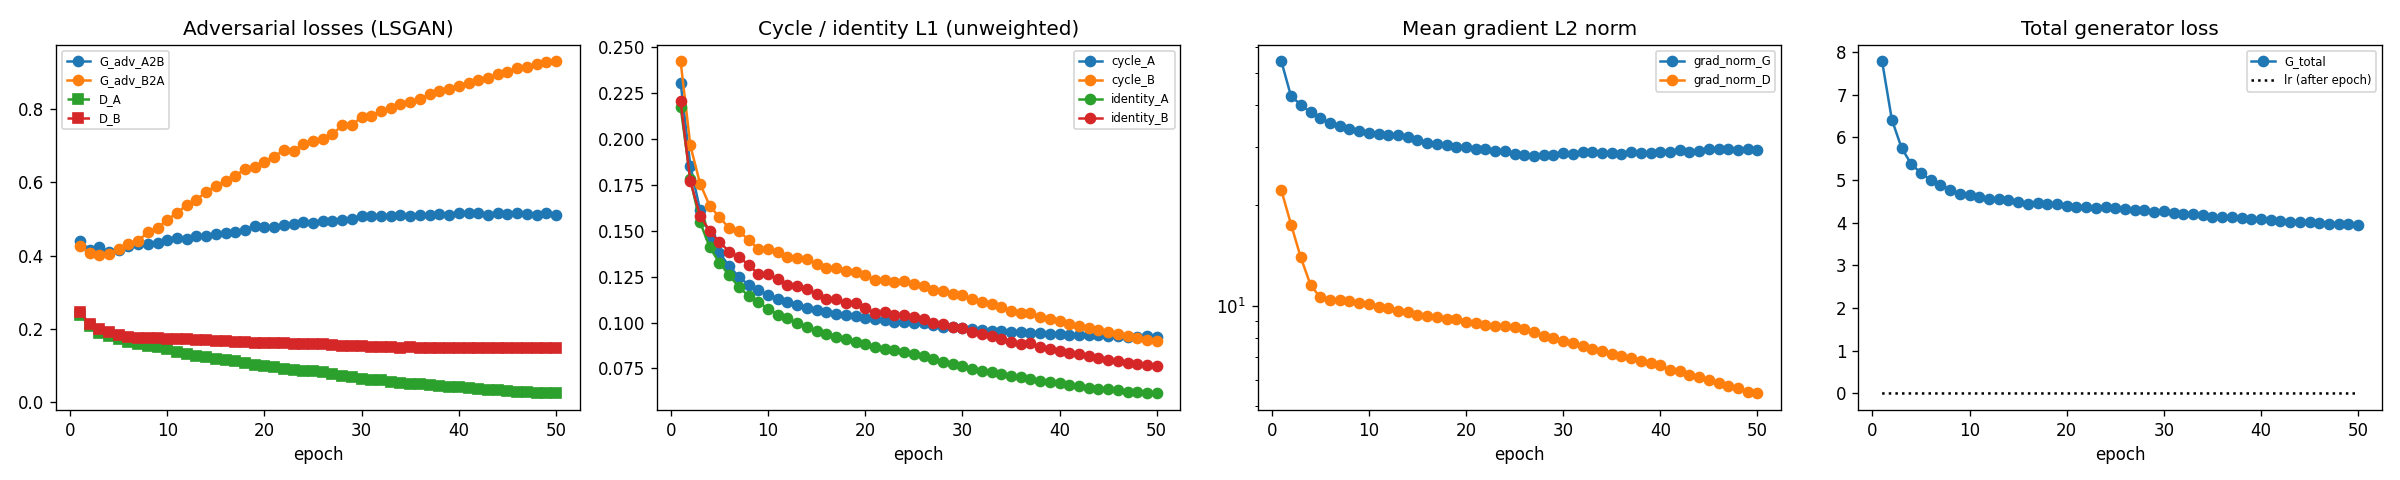

,epoch,G_total,G_adv_A2B,G_adv_B2A,cycle_A,cycle_B,identity_A,identity_B,D_A,D_B,grad_norm_G,grad_norm_D,lr,epoch_time_sec,train_images_per_sec
0,1,7.7819,0.4394,0.4261,0.2306,0.2421,0.2173,0.2205,0.2373,0.2455,54.1382,22.1945,0.0002,806.7268,14.9691
1,2,6.4185,0.4163,0.4084,0.1855,0.1964,0.1780,0.1769,0.2083,0.2135,42.5007,17.5334,0.0002,696.4686,17.3389
2,3,5.7565,0.4231,0.4014,0.1612,0.1756,0.1547,0.1582,0.1893,0.1990,40.1777,13.9609,0.0002,748.9623,16.1236
3,4,5.3743,0.4098,0.4032,0.1473,0.1635,0.1410,0.1497,0.1788,0.1916,38.0542,11.5521,0.0002,707.6028,17.0661
4,5,5.1666,0.4164,0.4187,0.1378,0.1573,0.1325,0.1438,0.1722,0.1839,36.6290,10.5934,0.0002,726.5845,16.6202
5,6,5.0017,0.4265,0.4309,0.1308,0.1514,0.1257,0.1386,0.1645,0.1782,35.3808,10.4064,0.0002,723.7470,16.6854
6,7,4.8940,0.4307,0.4407,0.1248,0.1499,0.1194,0.1359,0.1589,0.1752,34.6161,10.3810,0.0002,723.9874,16.6798
7,8,4.7782,0.4321,0.4637,0.1205,0.1449,0.1145,0.1312,0.1519,0.1752,33.9374,10.3381,0.0002,729.2986,16.5584
8,9,4.6810,0.4354,0.4761,0.1180,0.1402,0.1111,0.1265,0.1487,0.1734,33.3561,10.2032,0.0002,481.8452,25.0620
9,10,4.6584,0.4418,0.4984,0.1148,0.1402,0.1075,0.1262,0.1435,0.1712,32.9187,10.1254,0.0002,465.1922,25.9592


In [3]:
display(Image(out / "loss_curves.png"))
pd.read_csv(out / "train_history.csv").round(4)

## Full metrics (both directions)

In [4]:
pd.set_option("display.max_rows", 100)
pd.read_csv(out / "full_metrics_report.csv")

,direction,metric,value
0,A2B,FID,88.70866432466056
1,A2B,KID_mean,0.027239555176020745
2,A2B,KID_std,0.0010483586785759746
3,A2B,gen_precision,0.7533333333333333
4,A2B,gen_recall,0.356
5,A2B,gen_density,0.7266666666666667
6,A2B,gen_coverage,0.448
7,A2B,cycle_reconstruction_L1,0.04765860363841057
8,A2B,LPIPS_input_vs_translation,0.3878580629825592
9,A2B,LPIPS_input_vs_reconstruction,0.2572265565395355


## Sample translations over training

Rows: real Monet → fake Photo → reconstructed Monet → real Photo → fake Monet → reconstructed Photo (fixed held-out images).

epoch001.png


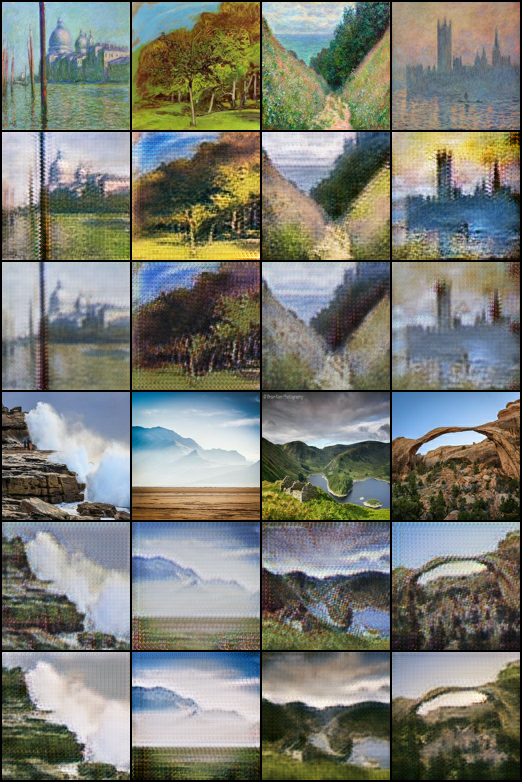

epoch026.png


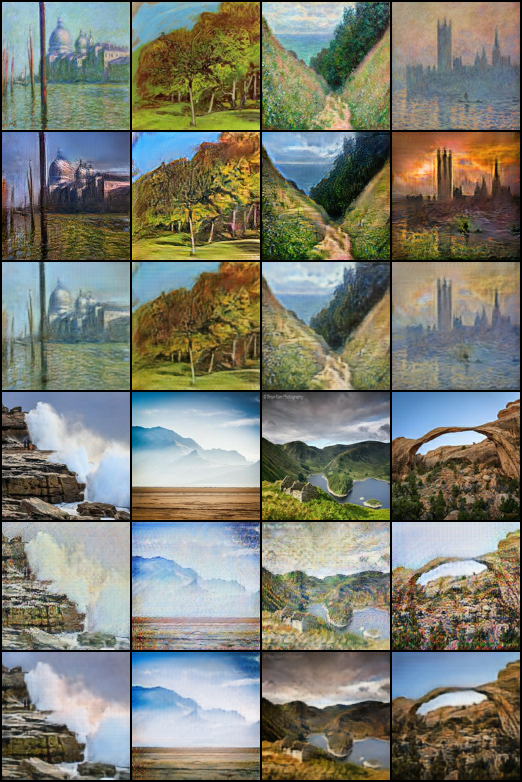

epoch050.png


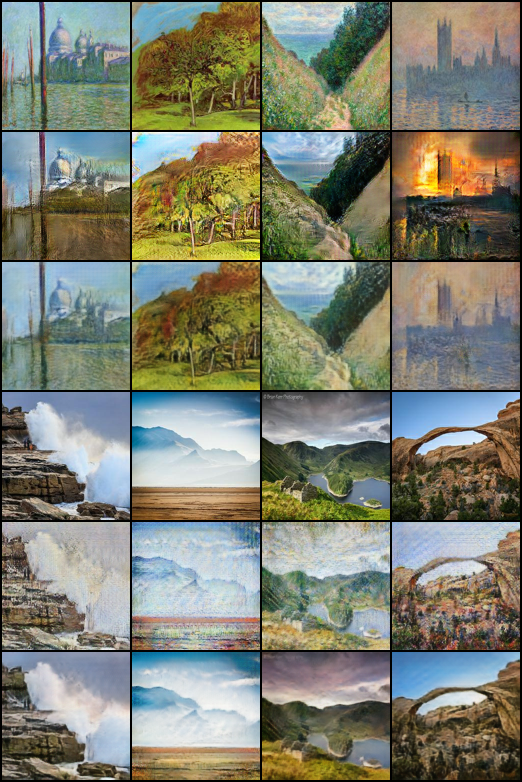

In [5]:
samples = sorted((out / "samples").glob("epoch*.png"))
for p in [samples[0], samples[len(samples) // 2], samples[-1]]:
    print(p.name); display(Image(p))

## Human audit

Blinded sheets are in `human_audit/` (images numbered, direction hidden in the answer key). Two raters fill `ratings_rater1.csv` / `ratings_rater2.csv`, then run:

```bash
python task3_gan/member_nikhil/src/audit_agreement.py task3_gan/member_nikhil/outputs/<run_id>/human_audit
```